# 01 — Metadados de Coleta e Execução

Este notebook avalia metadados de runs e spiders para identificar gargalos de execução e sinais de qualidade da coleta.


## Objetivo e escopo
- Medir eficiência operacional (volume, duração, throughput).
- Verificar qualidade de coleta (dedupe/invalid).
- Produzir sinais simples para acompanhamento contínuo.


## Fontes de dados
- `data/runs/<run_id>/run.json`
- `data/runs/<run_id>/items.jsonl` (apenas referência; este notebook usa `run.json`)


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if (ROOT / "notebooks").exists():
    NOTEBOOKS_DIR = ROOT / "notebooks"
else:
    NOTEBOOKS_DIR = ROOT
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [3]:
from eda_utils import load_runs_df, resolve_data_dir

data_dir = resolve_data_dir("/home/diacrono/Documentos/repositorios/fact-checking-scrape/data")
runs_df = load_runs_df(data_dir)

if runs_df.empty:
    print(f"Nenhum run encontrado em: {data_dir}")

runs_df.head()

,run_id,spider,agency_id,agency_name,run_started_at,run_finished_at,spider_started_at,spider_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid,run_duration_s,spider_duration_s,items_per_min
0,20260304T053909Z-4c2dcf13,reuters_fact_check,reuters,Reuters Fact Check,2026-03-04 05:39:10+00:00,2026-03-04 05:39:11+00:00,2026-03-04 05:39:10+00:00,2026-03-04 05:39:11+00:00,0,0,0,0,False,False,1.0,1.0,0.000000
1,20260304T055029Z-081fea3a,estadao_verifica,estadao_verifica,Estadao Verifica,2026-03-04 05:50:29+00:00,2026-03-04 06:27:49+00:00,2026-03-04 05:50:29+00:00,2026-03-04 06:27:49+00:00,5946,5946,0,0,True,True,2240.0,2240.0,159.267857
2,20260304T060438Z-06309984,g1_fato_ou_fake,g1_fato_ou_fake,G1 Fato ou Fake,2026-03-04 06:04:39+00:00,2026-03-04 06:16:14+00:00,2026-03-04 06:04:39+00:00,2026-03-04 06:16:14+00:00,3387,3387,0,0,True,True,695.0,695.0,292.402878
3,20260304T061715Z-80ac7ac6,uol_confere,uol_confere,UOL Confere,2026-03-04 06:17:15+00:00,2026-03-04 06:17:15+00:00,2026-03-04 06:17:15+00:00,2026-03-04 06:17:15+00:00,0,0,0,0,False,False,0.0,0.0,NaN
4,20260304T061917Z-94f0c15f,uol_confere,uol_confere,UOL Confere,2026-03-04 06:19:18+00:00,2026-03-04 06:19:18+00:00,2026-03-04 06:19:18+00:00,2026-03-04 06:19:18+00:00,0,0,0,0,False,False,0.0,0.0,NaN


## Resumo geral


In [4]:
summary = (
    runs_df.groupby("spider")[["items_seen", "items_stored", "items_deduped", "items_invalid"]]
    .sum()
    .sort_values("items_stored", ascending=False)
)

summary

,items_seen,items_stored,items_deduped,items_invalid
spider,,,,
boatos_org,12869,12869,0,0
observador,12658,8421,4237,0
estadao_verifica,11924,5978,5946,0
aos_fatos,4969,4936,33,0
e_farsas,4361,4361,0,0
afp_checamos,3982,3982,0,0
g1_fato_ou_fake,6799,3414,3385,0
uol_confere,3631,1826,1805,0
projeto_comprova,1607,1607,0,0


In [5]:
summary["items_stored"].sum()

np.int64(50887)

## Eficiência operacional


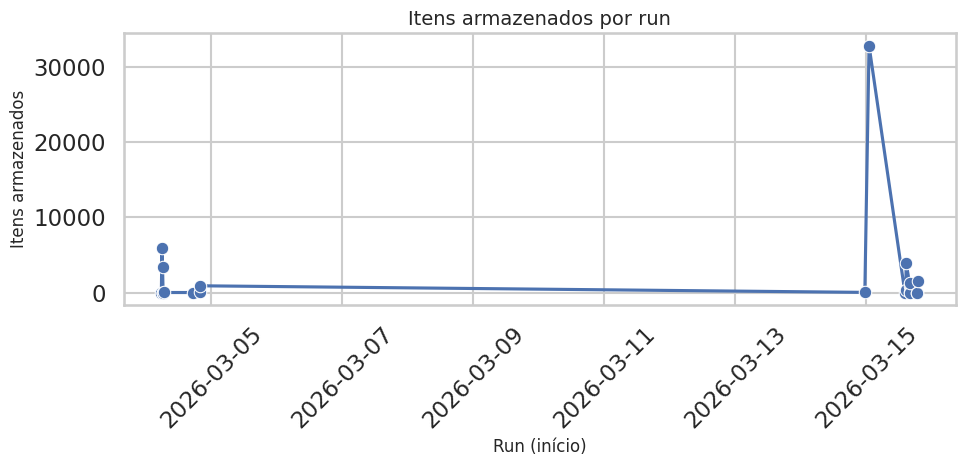

In [4]:
run_meta = runs_df.drop_duplicates("run_id")[["run_id", "run_started_at"]]
items_by_run = (
    runs_df.groupby("run_id")["items_stored"].sum().reset_index().merge(run_meta, on="run_id")
)
items_by_run = items_by_run.sort_values("run_started_at")

sns.lineplot(data=items_by_run, x="run_started_at", y="items_stored", marker="o")
plt.title("Itens armazenados por run")
plt.xlabel("Run (início)")
plt.ylabel("Itens armazenados")
plt.xticks(rotation=45)
plt.tight_layout()

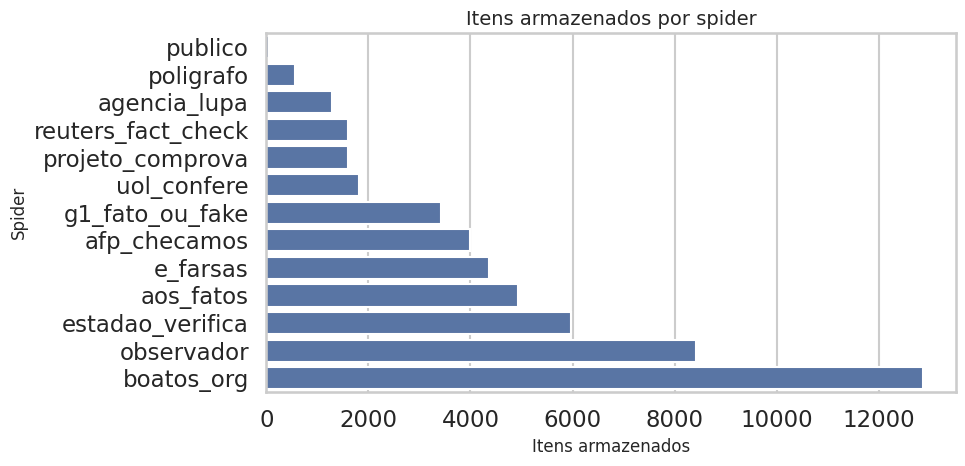

In [5]:
items_by_spider = (
    runs_df.groupby("spider", as_index=False)["items_stored"].sum().sort_values("items_stored")
)

sns.barplot(data=items_by_spider, x="items_stored", y="spider")
plt.title("Itens armazenados por spider")
plt.xlabel("Itens armazenados")
plt.ylabel("Spider")
plt.tight_layout()

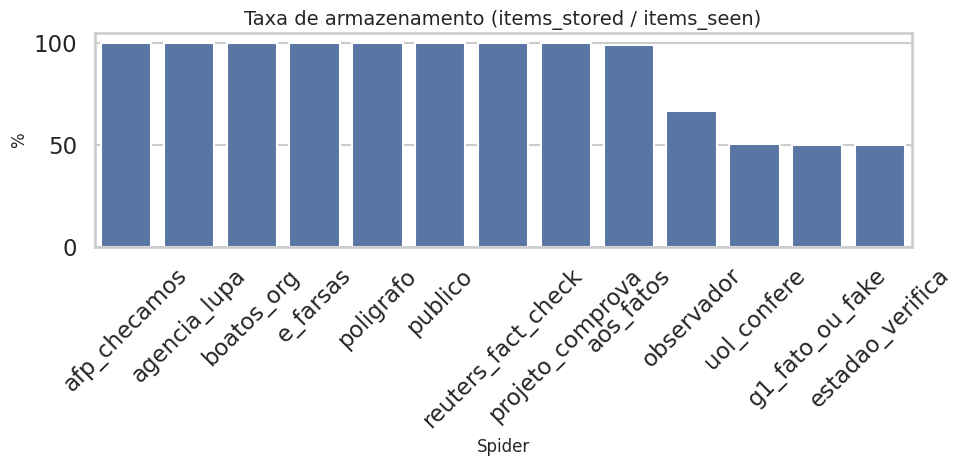

In [6]:
rate = runs_df.groupby("spider")[["items_seen", "items_stored"]].sum()
rate["storage_rate_pct"] = (rate["items_stored"] / rate["items_seen"] * 100).round(2)
rate = rate.reset_index().sort_values("storage_rate_pct", ascending=False)

sns.barplot(data=rate, x="spider", y="storage_rate_pct")
plt.title("Taxa de armazenamento (items_stored / items_seen)")
plt.xlabel("Spider")
plt.ylabel("%")
plt.xticks(rotation=45)
plt.tight_layout()

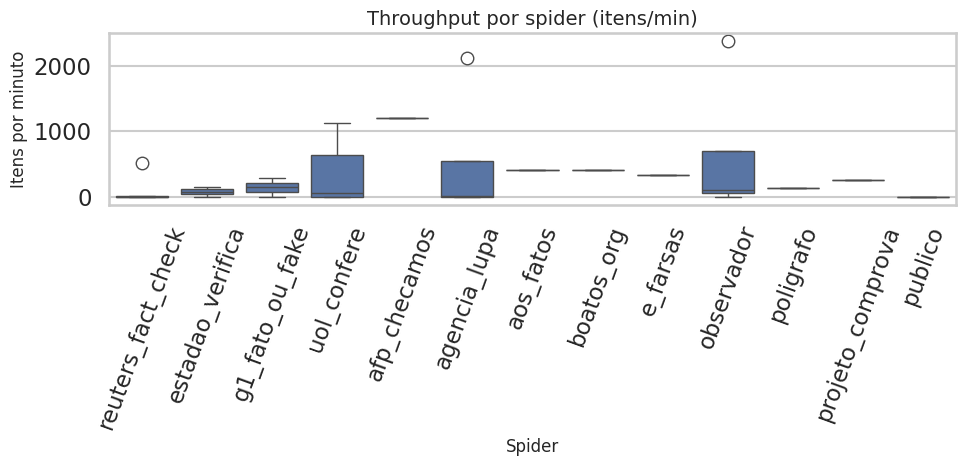

In [11]:
if "items_per_min" in runs_df.columns:
    sns.boxplot(data=runs_df, x="spider", y="items_per_min")
    plt.title("Throughput por spider (itens/min)")
    plt.xlabel("Spider")
    plt.ylabel("Itens por minuto")
    plt.xticks(rotation=70)
    plt.tight_layout()

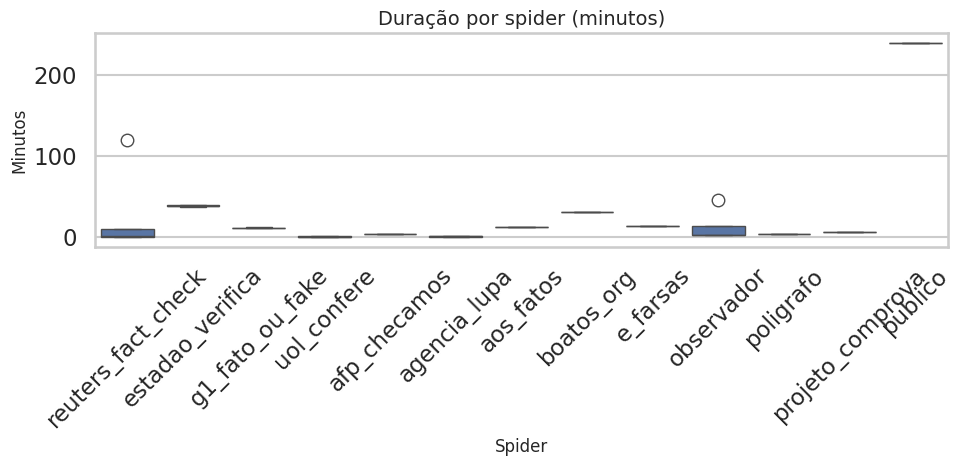

In [8]:
runs_df["spider_duration_min"] = runs_df["spider_duration_s"] / 60

sns.boxplot(data=runs_df, x="spider", y="spider_duration_min")
plt.title("Duração por spider (minutos)")
plt.xlabel("Spider")
plt.ylabel("Minutos")
plt.xticks(rotation=45)
plt.tight_layout()

## Qualidade da coleta


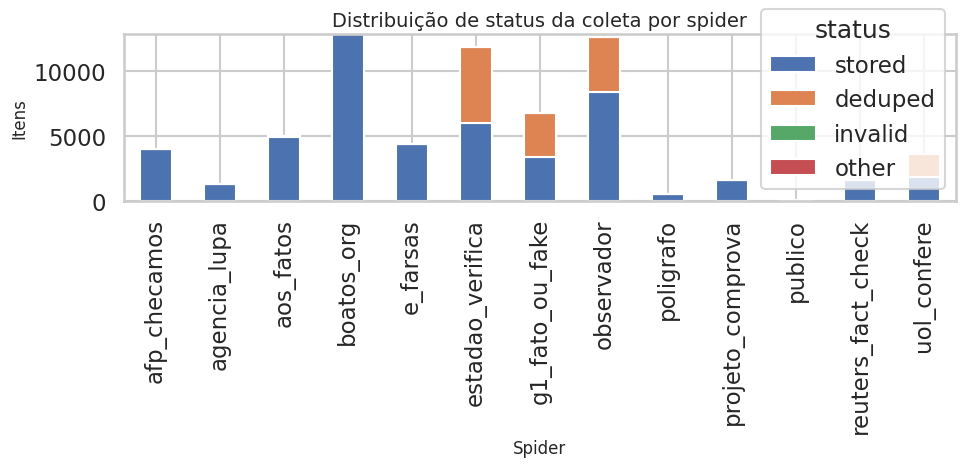

In [9]:
counts = runs_df.groupby("spider")[
    ["items_seen", "items_stored", "items_deduped", "items_invalid"]
].sum()
counts["items_other"] = (
    counts["items_seen"]
    - counts["items_stored"]
    - counts["items_deduped"]
    - counts["items_invalid"]
)

plot_df = counts[["items_stored", "items_deduped", "items_invalid", "items_other"]]
plot_df.plot(kind="bar", stacked=True)
plt.title("Distribuição de status da coleta por spider")
plt.xlabel("Spider")
plt.ylabel("Itens")
plt.legend(["stored", "deduped", "invalid", "other"], title="status")
plt.tight_layout()

## Achados e próximos passos
- Anotar padrões de throughput por spider.
- Identificar runs com baixa taxa de armazenamento.
- Priorizar spiders com maior taxa de invalid/deduped.
